In [143]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([[1, 2, 3]])
c = np.array([[1],
              [2],
              [3]])

print(a.shape)
print(b.shape)
print(c.shape)

(3,)
(1, 3)
(3, 1)


第一个代表的是一维数组，第二个和第三个代表的是二维矩阵。
一个[]放一个行向量，这样一行一行写过来

In [144]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print(A[1, 2])
print(A[:, 1])
print(A[1, :])
print(A[:2, :2])

6
[2 5 8]
[4 5 6]
[[1 2]
 [4 5]]


A[2,1]代表的是第3行第2列，和矩阵一样。不过需要注意的是，array是从0开始编号的

In [145]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("整体平均：", np.mean(A))
print("axis=0：", np.mean(A, axis=0))
print("axis=1：", np.mean(A, axis=1))

整体平均： 5.0
axis=0： [4. 5. 6.]
axis=1： [2. 5. 8.]


axis=0 表示沿着第 0 维进行运算，并把第 0 维消掉，因此二维矩阵中得到的是“每一列的结果”。
维数，例如[1,2]，分别是第0维，第1维

In [146]:
A = np.array(
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
    ]
)

b = np.array(
    [
        [10],
        [20],
        [30],
    ]
)

print("A.shape =", A.shape)
print("b.shape =", b.shape)

print(A + b)

A.shape = (3, 3)
b.shape = (3, 1)
[[11 12 13]
 [24 25 26]
 [37 38 39]]


相当于复制了好几份b，粘贴在一起，使得新的矩阵和A的大小相等

In [147]:
A = np.array([
    [2., 1.],
    [1., 3.]
])

B = np.array([
    [1., 2.],
    [3., 4.]
])

b = np.array([5., 7.])

print("对应元素相乘:")
print(A * B)

print("矩阵乘法:")
print(A @ B)

print("行列式：")
print(np.linalg.det(A))

print("逆矩阵：")
print(np.linalg.inv(A))

print("解 Ax = b:")
print(np.linalg.solve(A, b)) #为什么解出来的是一个一维数组，一维数组和矩阵相乘是不是就相当于一个列向量

print("特征值、特征向量")
eigenvalues, eigenvectors = np.linalg.eig(A) #这个没看懂是什么意思
print(eigenvalues)
print(eigenvectors)
# 验证
# v1 = eigenvectors[:,0]
# lambda1 = eigenvalues[0]
# print(A @ v1)
# print(lambda1 * v1)

print("秩：")
print(np.linalg.matrix_rank(A))


对应元素相乘:
[[ 2.  2.]
 [ 3. 12.]]
矩阵乘法:
[[ 5.  8.]
 [10. 14.]]
行列式：
5.000000000000001
逆矩阵：
[[ 0.6 -0.2]
 [-0.2  0.4]]
解 Ax = b:
[1.6 1.8]
特征值、特征向量
[1.38196601+0.j 3.61803399+0.j]
[[-0.85065081+0.j -0.52573111+0.j]
 [ 0.52573111+0.j -0.85065081+0.j]]
秩：
2


In [148]:
# 1. 求解 Ax=b
x = np.linalg.solve(A, b)
print(x)

# 2. 验证 Ax 是否约等于 b
print(np.allclose(A @ x, b))

# 3. 求 det(A)
print(np.linalg.det(A))

# 4. 求 A 的特征值和特征向量
values, vectors = np.linalg.eig(A)

# 5. 输出第一个特征值及其对应特征向量
v1 = vectors[:,0]
lambda2 = values[0]

# 6. 验证 Av = λv
print(A @ v1)
print(lambda2 * v1)

[1.6 1.8]
True
5.000000000000001
[-1.1755705 +0.j  0.72654253+0.j]
[-1.1755705 +0.j  0.72654253+0.j]


In [149]:
X = np.array([
    [170, 60, 80],
    [175, 70, 90],
    [180, 80, 100],
    [165, 55, 70],
    [185, 85, 95]
], dtype=float)

# 1. 每列均值
mean = np.mean(X, axis=0)

# 2. 每列标准差
std = np.std(X, axis=0)

# 3. Z-score 标准化
Z = (X - mean) / std

print("mean =", mean)
print("std =", std)
print("Z =")
print(Z)

# 4. 验证标准化后的每列均值约为 0
print(np.allclose(np.mean(Z, axis=0), 0))

# 5. 验证标准化后的每列标准差约为 1
print(np.allclose(np.std(Z, axis=0), 1))


mean = [175.  70.  87.]
std = [ 7.07106781 11.40175425 10.77032961]
Z =
[[-0.70710678 -0.87705802 -0.64993368]
 [ 0.          0.          0.27854301]
 [ 0.70710678  0.87705802  1.2070197 ]
 [-1.41421356 -1.31558703 -1.57841037]
 [ 1.41421356  1.31558703  0.74278135]]
True
True


In [150]:
#相关系数矩阵
R1 = np.corrcoef(X)
R2 = np.corrcoef(X, rowvar=False)

print("R1.shape =", R1.shape)
print(R1)

print()

print("R2.shape =", R2.shape)
print(R2)

R1.shape = (5, 5)
[[1.         0.99996096 0.99982661 0.99896777 0.99675404]
 [0.99996096 1.         0.99995212 0.99852737 0.99600371]
 [0.99982661 0.99995212 1.         0.99794872 0.9950821 ]
 [0.99896777 0.99852737 0.99794872 1.         0.99938216]
 [0.99675404 0.99600371 0.9950821  0.99938216 1.        ]]

R2.shape = (3, 3)
[[1.         0.99227788 0.91914503]
 [0.99227788 1.         0.93647712]
 [0.91914503 0.93647712 1.        ]]


In [151]:
#人工相关系数矩阵与numpy相关系数矩阵
R_manual = (Z.T @ Z) / X.shape[0]
R_numpy = np.corrcoef(X, rowvar=False)

print(R_manual)
print()
print(R_numpy)
print()
print(np.allclose(R_manual, R_numpy))

[[1.         0.99227788 0.91914503]
 [0.99227788 1.         0.93647712]
 [0.91914503 0.93647712 1.        ]]

[[1.         0.99227788 0.91914503]
 [0.99227788 1.         0.93647712]
 [0.91914503 0.93647712 1.        ]]

True


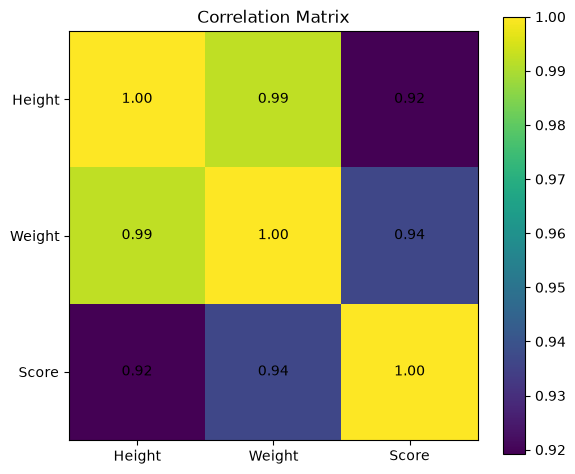

In [152]:
# 热力图
import matplotlib.pyplot as plt

R = np.corrcoef(X, rowvar=False)

plt.figure(figsize=(6, 5))  # 准备一张画布
plt.imshow(R)  # 把矩阵 R 画成颜色方块
plt.colorbar()  # 右边加颜色刻度

labels = ["Height", "Weight", "Score"]
plt.xticks(range(len(labels)), labels)  # x 轴标签
plt.yticks(range(len(labels)), labels)  # y 轴标签

for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        plt.text(
            j,
            i,
            f"{R[i, j]:.2f}",
            ha="center",
            va="center",
        )  # 往每个格子里写数字

plt.title("Correlation Matrix")  # 标题
plt.tight_layout()  # 自动整理排版
plt.show()  # 显示

```python
plt.figure(...)     # 准备一张画布

plt.imshow(R)       # 把矩阵 R 画成颜色方块
plt.colorbar()      # 右边加颜色刻度

plt.xticks(...)     # x 轴标签
plt.yticks(...)     # y 轴标签

plt.text(...)       # 往每个格子里写数字

plt.title(...)      # 标题
plt.tight_layout()  # 自动整理排版
plt.show()          # 显示
```

plt.text(j, i, ...)是 j 在前，i 在后，因为画图坐标是：(x, y)=(列, 行)
而矩阵访问是：R[行, 列]=R[i, j]
所以才写成：
plt.text(j, i, R[i, j])

In [153]:
def standardize(X):
    # 1. 确保输入是二维数组
    if X.ndim != 2:
        raise ValueError("X不是二维数组！")

    # 2. 求每列均值和标准差
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    
    # 3. 如果有某列 std == 0，报错
    if (np.any(np.isclose(std, 0))): # np.any() 任意一个为True则返回True, np.all() 全部为True才返回True， 二者都可以把布尔型的数组转化为单值的数组
        raise ValueError("存在标准差为0的列，无法标准化")
    
    # 4. 返回标准化结果
    Z = (X - mean) / std
    return Z

In [154]:
# 正常数据
X1 = np.array(
    [
        [1, 10],
        [2, 20],
        [3, 30],
    ],
    dtype=float,
)

# 有常数列
X2 = np.array(
    [
        [1, 100],
        [2, 100],
        [3, 100],
    ],
    dtype=float,
)

Z1 = standardize(X1)
print(Z1)

try:
    Z2 = standardize(X2)
except ValueError as e:
    print("捕获到异常：", e)

[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]
捕获到异常： 存在标准差为0的列，无法标准化


In [155]:
# 对比循环和向量化的写法：
Z_loop = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_loop[i, j] = (X[i, j] - mean[j]) / std[j]

Z_vectorized = (X - mean) / std

print(np.allclose(Z_loop, Z_vectorized))

True


In [ ]:
# 测试模块化代码
from src.numerical_utils import standardize

X_test = np.array([
    [1, 10],
    [2, 20],
    [3, 30]
])

Z_test = standardize(X_test)

print(np.mean(Z_test, axis=0))
print(np.std(Z_test, axis=0))

[0. 0.]
[1. 1.]
